In [47]:
%reload_ext autoreload
%autoreload 2
!nvidia-smi

Mon Mar  9 15:26:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.02              Driver Version: 581.42         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:01:00.0  On |                  N/A |
| 30%   40C    P1             72W /  575W |    3582MiB /  32607MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [48]:
import torch
if not hasattr(torch.Tensor, '_original_repr'):
    torch.Tensor._original_repr = torch.Tensor.__repr__
    torch.Tensor.__repr__ = lambda self: f"{self.shape} {torch.Tensor._original_repr(self)}"

import sys

In [49]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pennylane as qml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import os
import time
from tqdm.notebook import tqdm # Use notebook version of tqdm
import matplotlib.pyplot as plt

# Custom local imports (Ensure these files are in the same directory)
import dataloader.adult_dataloader as adult_dataloader
import InputEmbeddings
import bias_calculation
from seed import set_seed
import models.quantum_circuits as quantum_circuits
import models.models as models

# Configure Plotting Style
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 8)

In [50]:
class Config:
    epochs : int = 20
    n_qubits : int = 7
    n_layers : int = 10
    hidden_dim : int = 16
    learning_rate : float = 1e-3
    batch_size : int = 512
    run_name : str = f"Qubits-{n_qubits}_Ang_TrnEbding"
    seed : int = 42
    device : str = 'cuda'
    dev =qml.device('default.qubit', wires=n_qubits)# if device == 'cpu' else qml.device('lightning.gpu', wires=n_qubits)
    diff_method : str = "backprop"# if device == 'cpu' else "adjoint"
cfg = Config()

In [51]:
# Ensure reproducibility
set_seed(cfg.seed)

cpu_count = os.cpu_count()
num_workers = 4 if cpu_count > 4 and cfg.device == 'cpu' else 0

print(f"Using device: {cfg.device}")
print(f"Number of CPU cores: {cpu_count}, Setting num_workers to: {num_workers}")
print(f"Hyperparameters: epochs={cfg.epochs}, n_qubits={cfg.n_qubits}, n_layers={cfg.n_layers}, lr={cfg.learning_rate}, batch_size={cfg.batch_size}, run_name={cfg.run_name}")

Using device: cuda
Number of CPU cores: 24, Setting num_workers to: 0
Hyperparameters: epochs=20, n_qubits=7, n_layers=10, lr=0.001, batch_size=512, run_name=Qubits-7_Ang_TrnEbding


In [52]:
# Load and Preprocess Data
X_train, X_test, y_train, y_test, sens_train, sens_test = adult_dataloader.load_and_preprocess_data()

# Optional: Feature Engineering (Commented out in original)
# X_train, X_test = InputEmbeddings.apply_pca(X_train, X_test, n_qubits) 
# X_train, X_test, n_qubits = prepare_amplitude_encoding(X_train, X_test) 

# Convert to Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(cfg.device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(cfg.device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(cfg.device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(cfg.device)
sens_test_t = sens_test 

# Create DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=num_workers)

print(f"Data Loaded. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Loading and preprocessing data...
Data Loaded. Train shape: (30162, 101), Test shape: (15060, 101)


In [53]:
from models.mlp import HybridMLP
from utils.misc import count_parameters
model = HybridMLP(
    n_qubits=cfg.n_qubits, 
    n_layers=cfg.n_layers, 
    input_dim=X_train.shape[1],
    dev=cfg.dev,
    diff_method=cfg.diff_method
    ).to(cfg.device)
_ = count_parameters(model)

Total params: 932
Train params: 932


In [54]:
optimizer = optim.AdamW(model.parameters(), lr=cfg.learning_rate)
criterion = nn.BCEWithLogitsLoss()

print(f"\nStarting mini-batch training (Batch Size: {cfg.batch_size}, Qubits: {cfg.n_qubits})")
start_train = time.time()

# Lists to store metrics for visualization
history_loss = []
history_acc = []

for epoch in range(cfg.epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(cfg.device), batch_y.to(cfg.device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        # Record metrics per step
        current_loss = loss.item()
        total_loss += current_loss
            
        # Calculate batch accuracy
        preds = (torch.sigmoid(outputs) > 0.5).float()
        acc = (preds == batch_y).float().mean().item()
            
        history_loss.append(current_loss)
        history_acc.append(acc)

    
    avg_loss = total_loss / len(train_loader)
    if (epoch+1) % 1 == 0:
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_t)
            # Store raw probabilities for visualization later
            test_probs = torch.sigmoid(test_outputs).cpu().numpy().flatten()
            predictions = (test_probs > 0.5).astype(float)
            y_test_numpy = y_test_t.cpu().numpy().flatten().astype(int)

        # Standard Accuracy
        acc = accuracy_score(y_test_numpy, predictions)
        print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f} | Test Accuracy: {acc:.4f}")
        model.train()

print(f"Training time: {time.time() - start_train:.2f}s")


Starting mini-batch training (Batch Size: 512, Qubits: 7)
Epoch 1 Average Loss: 0.6242 | Test Accuracy: 0.8070
Epoch 2 Average Loss: 0.5437 | Test Accuracy: 0.8220
Epoch 3 Average Loss: 0.5117 | Test Accuracy: 0.8350
Epoch 4 Average Loss: 0.4986 | Test Accuracy: 0.8382
Epoch 5 Average Loss: 0.4914 | Test Accuracy: 0.8382
Epoch 6 Average Loss: 0.4867 | Test Accuracy: 0.8424
Epoch 7 Average Loss: 0.4836 | Test Accuracy: 0.8426
Epoch 8 Average Loss: 0.4812 | Test Accuracy: 0.8461
Epoch 9 Average Loss: 0.4796 | Test Accuracy: 0.8440
Epoch 10 Average Loss: 0.4782 | Test Accuracy: 0.8433
Epoch 11 Average Loss: 0.4771 | Test Accuracy: 0.8447
Epoch 12 Average Loss: 0.4762 | Test Accuracy: 0.8459
Epoch 13 Average Loss: 0.4756 | Test Accuracy: 0.8462
Epoch 14 Average Loss: 0.4750 | Test Accuracy: 0.8438
Epoch 15 Average Loss: 0.4745 | Test Accuracy: 0.8452
Epoch 16 Average Loss: 0.4739 | Test Accuracy: 0.8469
Epoch 17 Average Loss: 0.4735 | Test Accuracy: 0.8478
Epoch 18 Average Loss: 0.4732 | 

In [55]:
model.eval()
print("\nTesting and evaluating bias...")

with torch.no_grad():
    test_outputs = model(X_test_t)
    # Store raw probabilities for visualization later
    test_probs = torch.sigmoid(test_outputs).cpu().numpy().flatten()
    predictions = (test_probs > 0.5).astype(float)
    y_test_numpy = y_test_t.cpu().numpy().flatten().astype(int)

# Standard Accuracy
acc = accuracy_score(y_test_numpy, predictions)

# Bias Metrics
dpd, prob_female, prob_male = bias_calculation.demographic_parity(predictions, sens_test_t)
eod, tpr_diff, fpr_diff = bias_calculation.equalized_odds(predictions, y_test_numpy, sens_test_t)

print("-" * 30)
print(f"Model accuracy (Accuracy): {acc:.4f}")
print("\n[Bias analysis (based on sex)]")
print(f"Probability of being predicted >50K for female: {prob_female:.4%}")
print(f"Probability of being predicted >50K for male: {prob_male:.4%}")
print(f"Demographic parity difference (DPD): {dpd:.4f}")
print(f"True Positive Rate difference (TPR diff): {tpr_diff:.4f}")
print(f"False Positive Rate difference (FPR diff): {fpr_diff:.4f}")
print(f"Equalized Odds difference (EOD): {eod:.4f}")
print("-" * 30)


Testing and evaluating bias...
------------------------------
Model accuracy (Accuracy): 0.8473

[Bias analysis (based on sex)]
Probability of being predicted >50K for female: 7.3275%
Probability of being predicted >50K for male: 22.7949%
Demographic parity difference (DPD): 0.1547
True Positive Rate difference (TPR diff): 0.0669
False Positive Rate difference (FPR diff): 0.0592
Equalized Odds difference (EOD): 0.0669
------------------------------


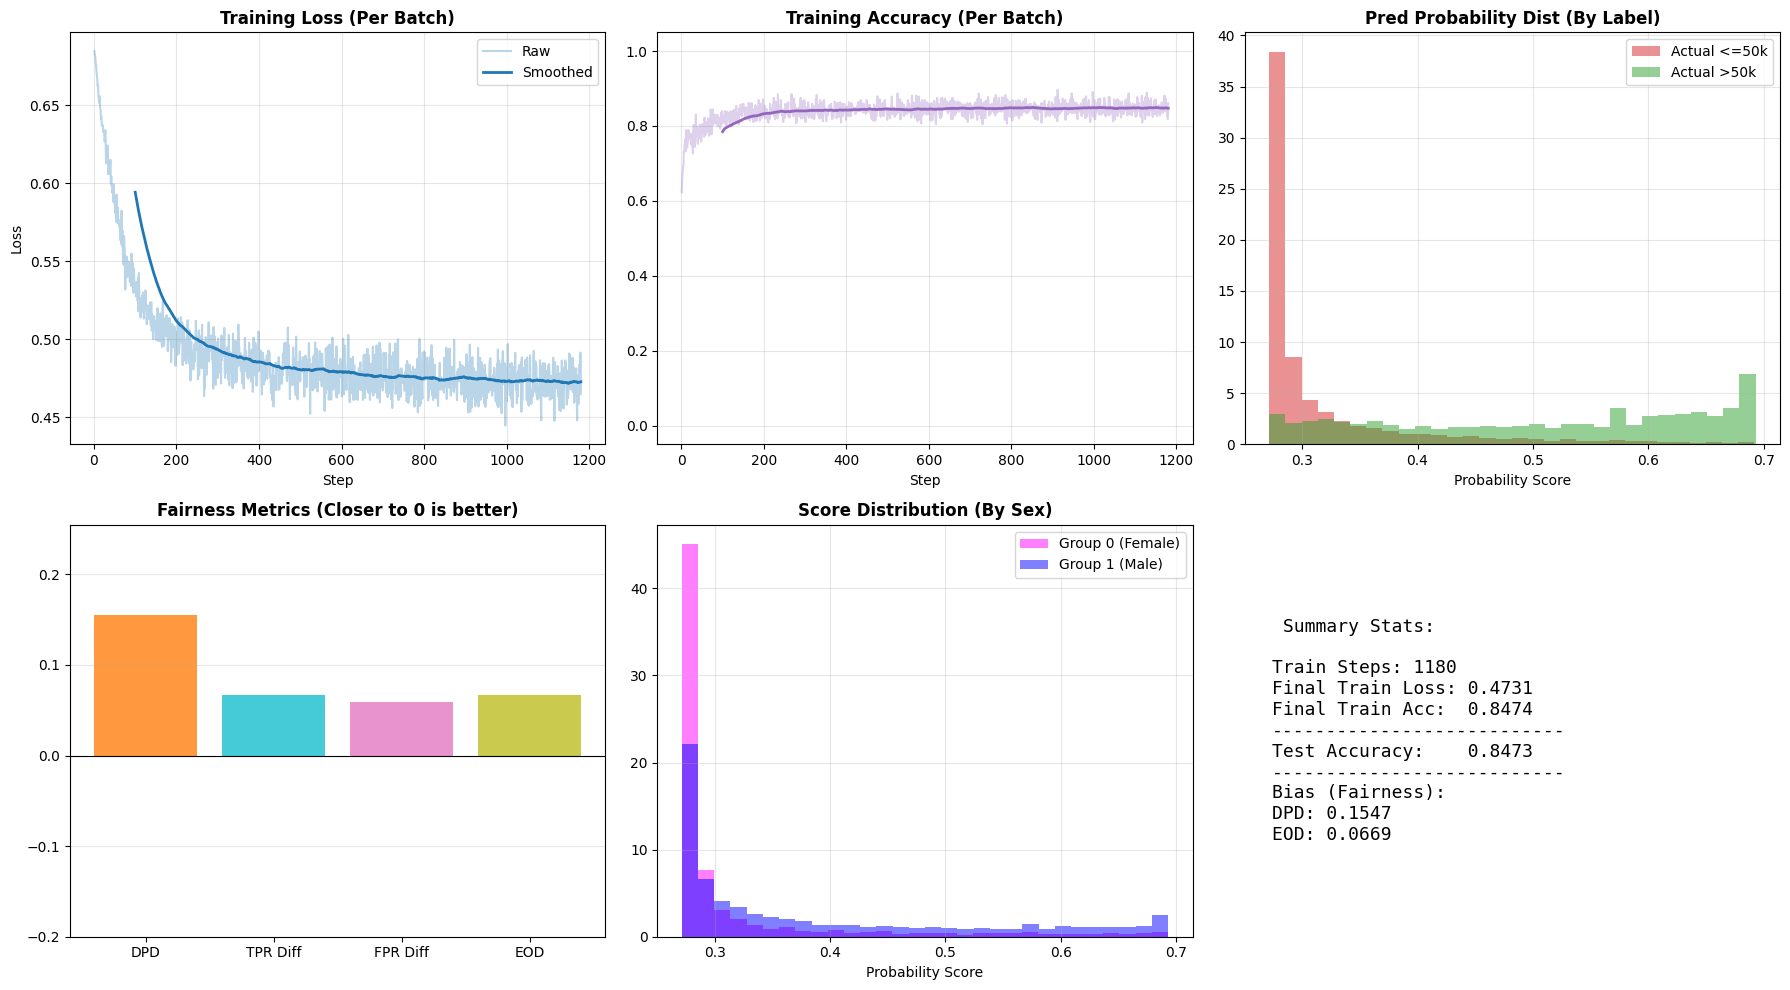

In [56]:
from utils.diagnostics import visualize_results

bias_dict = {
    'dpd': dpd,
    'tpr_diff': tpr_diff,
    'fpr_diff': fpr_diff,
    'eod': eod
}
visualize_results(history_loss, history_acc, test_probs, y_test_numpy, sens_test_t, bias_dict)